In [1]:
from ezfalcon.simulation import Sim
import astropy.units as u


import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'font.size': 14, 'axes.labelsize': 16,
    'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
    'ytick.right': True, 'xtick.top': True,
    'mathtext.fontset': 'stix',
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
})

In [2]:
pos = np.load('script_output/data/shell_pos.npy')
vel = np.load('script_output/data/shell_vel.npy')
mass = np.load('script_output/data/shell_mass.npy')
self_PE = np.load('script_output/data/self_PE.npy')
star_mask = np.load('script_output/data/star_mask.npy')
bound_mask = np.load('script_output/data/bound_mask.npy')
times = np.load('script_output/data/times.npy')

In [3]:
shell = Sim()
shell._positions = pos
shell._velocities = vel
shell._masses = mass
shell._self_PE = self_PE
shell._times = times

In [4]:
def calculate_star_mask(vel, mass, self_PE):
    center_vel = np.mean(vel, axis=0)
    binding = self_PE + 0.5 * mass* np.sum((vel - center_vel)**2, axis=1)
    sorted_binding_indices = np.argsort(binding)
    return sorted_binding_indices[:int(0.1*len(binding))]

star_mask = calculate_star_mask(vel[0], mass, self_PE[0])

In [5]:
is_star = np.zeros(shell.x(-1).shape[0], dtype=bool)
is_star[star_mask] = True

not_star_idx = np.where(~is_star)[0]      # indices of non-stars
x_not_star = shell.x(-1)[~is_star]        # x values of non-stars
y_not_star = shell.y(-1)[~is_star]        # y values of non-stars

Text(0, 0.5, 'y [kpc]')

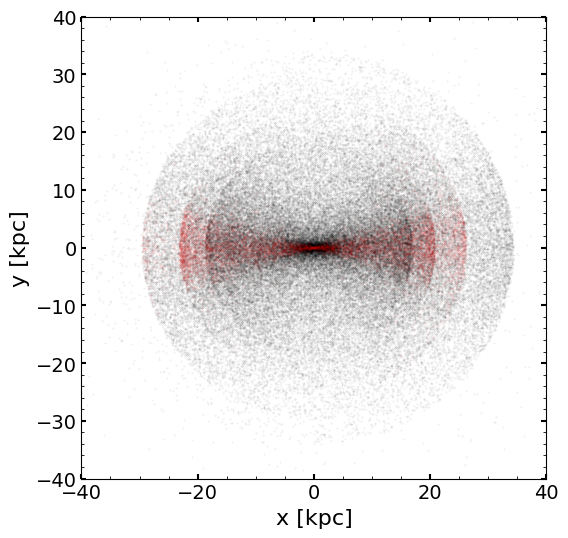

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(shell.x(-1)[~is_star], shell.y(-1)[~is_star], s=0.1, alpha=0.1, c='k')
plt.scatter(shell.x(-1)[is_star], shell.y(-1)[is_star], s=0.1, alpha=0.1, c='r')
plt.xlim(-40, 40)
plt.ylim(-40, 40)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

Text(0, 0.5, 'y [kpc]')

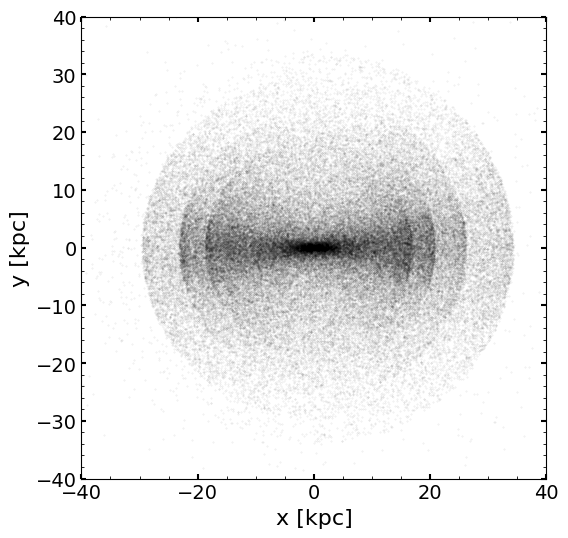

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(shell.x(-1), shell.y(-1), s=0.1, alpha=0.1, c='k')
plt.xlim(-40, 40)
plt.ylim(-40, 40)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Transfer to galpy

In [8]:
from galpy.util.coords import rect_to_cyl, rect_to_cyl_vec

R_all, phi_all, z_all = rect_to_cyl(shell.x(-1)*u.kpc, shell.y(-1)*u.kpc, shell.z(-1)*u.kpc)
vR_all, vT_all, vz_all = rect_to_cyl_vec(shell.vx(-1)*u.kpc/u.Myr, shell.vy(-1)*u.kpc/u.Myr, shell.vz(-1)*u.kpc/u.Myr, shell.x(-1)*u.kpc, shell.y(-1)*u.kpc, shell.z(-1)*u.kpc)

R_stars, phi_stars, z_stars = rect_to_cyl(shell.x(-1)[star_mask]*u.kpc, shell.y(-1)[star_mask]*u.kpc, shell.z(-1)[star_mask]*u.kpc)
vR_stars, vT_stars, vz_stars = rect_to_cyl_vec(shell.vx(-1)[star_mask]*u.kpc/u.Myr, shell.vy(-1)[star_mask]*u.kpc/u.Myr, shell.vz(-1)[star_mask]*u.kpc/u.Myr, shell.x(-1)[star_mask]*u.kpc, shell.y(-1)[star_mask]*u.kpc, shell.z(-1)[star_mask]*u.kpc)

In [9]:
from galpy.orbit import Orbit
o_all = Orbit([R_all, vR_all, vT_all, z_all, vz_all, phi_all])
o_stars = Orbit([R_stars, vR_stars, vT_stars, z_stars, vz_stars, phi_stars])

Text(0, 0.5, 'y [kpc]')

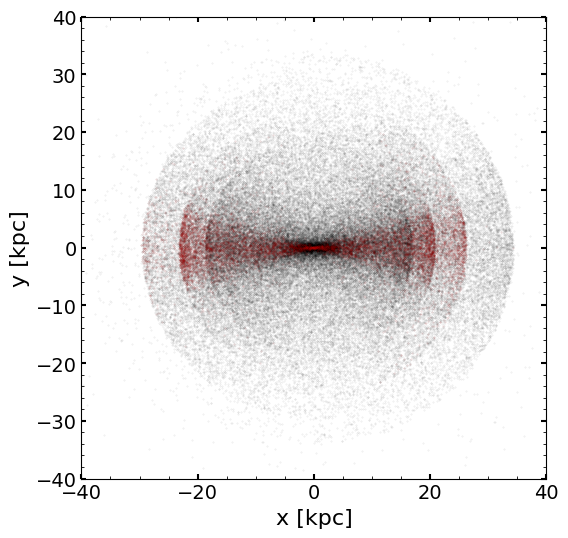

In [10]:
# Make sure the transfer to galpy worked.

plt.figure(figsize=(6, 6))
plt.scatter(o_all.x(), o_all.y(), s=0.1, alpha=0.1, c='k')
plt.scatter(o_stars.x(), o_stars.y(), s=0.1, alpha=0.1, c='r')
plt.xlim(-40, 40)
plt.ylim(-40, 40)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

Text(0, 0.5, '$v_r$ [kpc/Myr]')

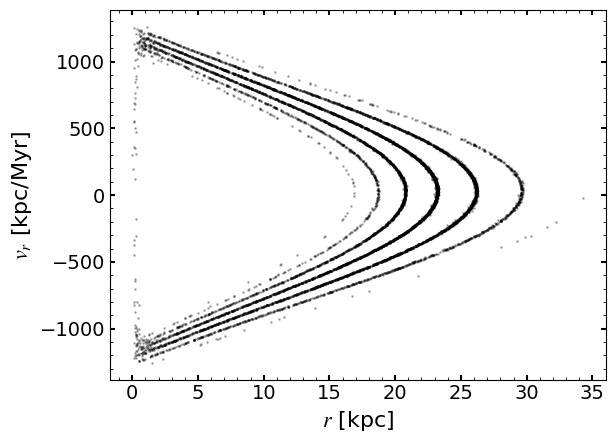

In [11]:
plt.scatter(o_stars.r(), o_stars.vr(), s=1, alpha=0.25, c='k')
plt.xlabel('$r$ [kpc]')
plt.ylabel('$v_r$ [kpc/Myr]')

In [12]:
from galpy.potential import NFWPotential
host_pot = NFWPotential(amp=1e13 * u.Msun, a=20*u.kpc)

In [28]:
skip = 10
#unbound_mask = o_stars.E(pot=host_pot) > -1e6
#o_bound_stars = Orbit([R_stars[~unbound_mask][::50], vR_stars[~unbound_mask][::50], vT_stars[~unbound_mask][::50], z_stars[~unbound_mask][::50], vz_stars[~unbound_mask][::50], phi_stars[~unbound_mask][::50]])
o_bound_stars = Orbit([R_stars[::skip], vR_stars[::skip], vT_stars[::skip], z_stars[::skip], vz_stars[::skip], phi_stars[::skip]])

In [29]:
from galpy.actionAngle import actionAngleAdiabatic, actionAngleSpherical
aA = actionAngleAdiabatic(pot=host_pot)
aAS = actionAngleSpherical(pot=host_pot)
jr,jphi,jz,Or,Ophi,Oz,angler,anglephi,anglez = aAS.actionsFreqsAngles(o_bound_stars)

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/util/quadpack.py:135: AccuracyWarning: maxiter (50) exceeded. Latest difference = 5.626657e-08
  warnings.warn(

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/util/quadpack.py:135: AccuracyWarning: maxiter (50) exceeded. Latest difference = 9.451922e-08
  warnings.warn(

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/util/quadpack.py:135: AccuracyWarning: maxiter (50) exceeded. Latest difference = 2.884397e-06
  warnings.warn(

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/util/quadpack.py:135: AccuracyWarning: maxiter (50) exceeded. Latest difference = 2.620882e-05
  warnings.warn(

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/util/quadpack.py:135: AccuracyWarning: maxiter (50) exceeded. Latest difference = 5.633354e-08
  warnings.warn(



In [32]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Scatter3d(
    x=angler,
    y=anglephi,
    z=anglez,
    mode='markers',
    marker=dict(
        size=1,
        color=jr,  # Color points by radial action
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="jr")
    )
)])

fig.update_layout(
    title='Action Angles: angler vs anglephi vs anglez',
    scene=dict(
        xaxis_title='angler',
        yaxis_title='anglephi',
        zaxis_title='anglez'
    ),
    width=900,
    height=700
)

fig.show()

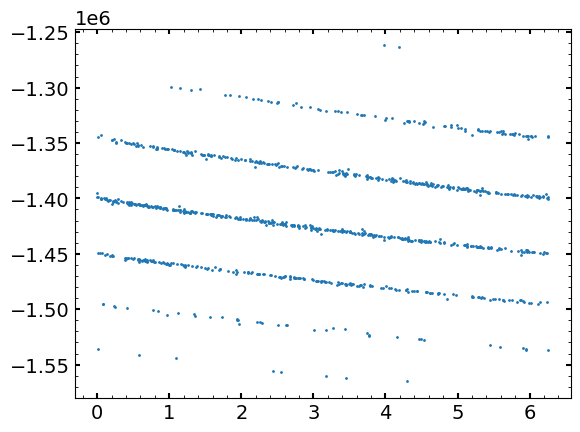

In [34]:
plt.scatter(angler, o_stars.E(pot=host_pot)[::skip], s=1, alpha=1)